# 01 · Explore & clean
**Question:** what does weekly demand look like per region — trend, seasonality, data quality?

Data: Walmart **M5** (30,490 item-store series, 10 stores in CA/TX/WI, 2011-01-29 → 2016-05-22), used as a proxy for pharmacy/retail unit demand. Regions: CA→West, TX→South, WI→Midwest. Aggregation is done in `src/prepare_data.py` (store-day → store-week using Walmart's Sat–Fri `wm_yr_wk`, partial weeks dropped); SQL below runs against the SQLite file it writes.

In [1]:
import sqlite3, re, pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.width", 160)
con = sqlite3.connect("../data/processed/supply_chain.db")
reg = pd.read_csv("../data/processed/regional_weekly_volume.csv", parse_dates=["week_start"])
def sql(n):  # run query Qn from sql/01_explore.sql
    blk = [b for b in re.split(r"\n(?=-- Q\d)", open("../sql/01_explore.sql").read()) if b.startswith(f"-- Q{n}:")][0]
    return pd.read_sql(blk.split("\n", 1)[1], con)

## Data quality

In [2]:
dq = pd.read_csv("../data/processed/data_quality_summary.csv", index_col=0)
dq

,value
item_store_series,30490
days,1941
date_min,2011-01-29
date_max,2016-05-22
missing_values_in_sales,0
duplicate_ids,0
negative_sales,0
pct_zero_item_days,68.0
store_days_with_zero_total,24
calendar_gaps,0


Findings: no missing values, duplicate ids, negative sales or calendar gaps. 68% of item-days are zero (normal for intermittent retail demand — which is why we forecast at region-week level, not item level). 24 store-days have zero total sales (store-closure days such as Christmas) — immaterial once summed to weeks.

In [3]:
sql(4)

,region,weeks,first_week,last_week
0,Midwest,277,2011-01-29,2016-05-14
1,South,277,2011-01-29,2016-05-14
2,West,277,2011-01-29,2016-05-14


All three regions have the same 277 complete weeks → no alignment problems.

## Trend — yearly volume and growth (SQL)

In [4]:
y = sql(1).query("yr <= '2015'")   # 2011 and 2016 are partial years
y.pivot(index='yr', columns='region', values='units')

region,Midwest,South,West
yr,,,
2011,2245085,2761320,4018516
2012,3177341,3597021,5245393
2013,3612078,3769039,5723750
2014,3661646,3664192,5734655
2015,3964063,3850160,5953154


In [5]:
y.pivot(index='yr', columns='region', values='yoy_pct')

region,Midwest,South,West
yr,,,
2011,NaN,NaN,NaN
2012,41.5,30.3,30.5
2013,13.7,4.8,9.1
2014,1.4,-2.8,0.2
2015,8.3,5.1,3.8


2011 and 2016 are partial years (the data starts late January 2011 and ends May 2016), so 2012's jump and any 2016 total are not comparable. From 2013 growth is modest: West 9% → 0% → 4%, South 5% → −3% → 5%, Midwest 14% → 1% → 8% (2013 → 2014 → 2015). Midwest is the fastest-growing region and is still climbing in 2016.

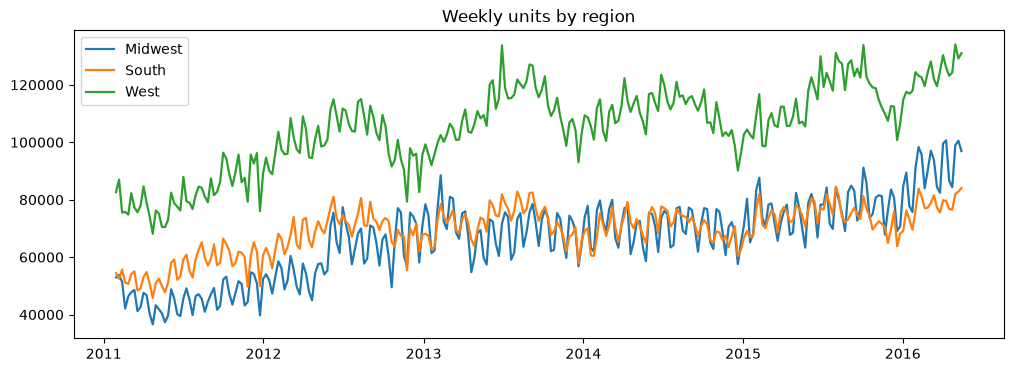

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
for r, g in reg.groupby("region"):
    ax.plot(g.week_start, g.units, label=r, lw=1.6)
ax.set_title("Weekly units by region"); ax.legend(); plt.show()

## Seasonality (SQL index, 2012-2015)

In [7]:
si = sql(2).pivot(index="month", columns="region", values="seasonal_index")
si.round(3)

region,Midwest,South,West
month,,,
1,0.958,0.914,0.917
2,1.020,0.992,0.947
3,0.978,0.996,0.975
4,0.930,0.998,0.983
5,0.957,1.007,0.991
6,1.026,1.067,1.073
7,1.003,1.043,1.052
8,1.042,1.068,1.094
9,1.031,1.034,1.063


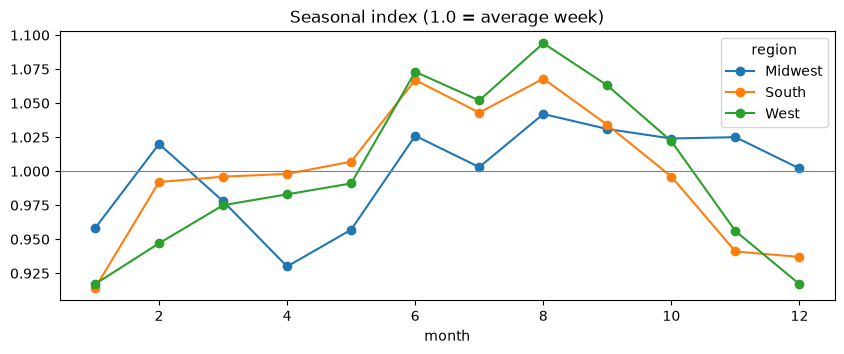

In [8]:
si.plot(figsize=(10, 3.5), marker="o", title="Seasonal index (1.0 = average week)"); plt.axhline(1, color="grey", lw=.8); plt.show()

West and South run 4–9% above average from June to September (West peaks in August at 1.09) and 5–9% below average in November–January (West December and January are both 0.92). Midwest is flatter (0.93–1.04). The yearly cycle is clear enough to model with yearly seasonality.

## Concentration and mix

In [9]:
sql(3)

,region,store_id,units,pct_of_region
0,Midwest,WI_1,5251450,28.4
1,Midwest,WI_2,6687707,36.2
2,Midwest,WI_3,6533281,35.4
3,South,TX_1,5684032,29.6
4,South,TX_2,7319623,38.1
5,South,TX_3,6196254,32.3
6,West,CA_1,7820195,26.8
7,West,CA_2,5804661,19.9
8,West,CA_3,11348323,38.9
9,West,CA_4,4175791,14.3


In [10]:
sql(5)

,region,cat_id,units,pct
0,Midwest,FOODS,3066021,70.3
1,Midwest,HOBBIES,345675,7.9
2,Midwest,HOUSEHOLD,948052,21.7
3,South,FOODS,2566881,63.9
4,South,HOBBIES,385947,9.6
5,South,HOUSEHOLD,1062810,26.5
6,West,FOODS,4088196,63.9
7,West,HOBBIES,719058,11.2
8,West,HOUSEHOLD,1589122,24.8


**Takeaways for Part 2:** (1) upward trend + yearly seasonality → use models with both; (2) West is 44% of volume, South 29%, Midwest 28%; (3) FOODS is 63–70% of units everywhere, so regional mix is similar and region-level forecasting is appropriate.